# Prophet buy/hold signals: backtested

This is a reworked version of `Value_Notebook.04`, which is left
unchanged for reference. The model is the same Prophet setup as in .04
(`changepoint_prior_scale=0.1`, `seasonality_prior_scale=1`), and the
trading rule is the same idea: hold the stock when Prophet forecasts the
price to rise. What changed:

- **All eight stocks in `stock_dataXL.xlsx`, not only Sberbank**, so the
  result doesn't depend on one stock.
- **Dates line up.** The sheets are newest-first; .04 compared forecasts
  in date order with prices in reverse order. Prices are now sorted, and
  forecasts are made for the actual trading days instead of calendar days.
- **No look-ahead.** A decision made at a day's close is traded at the
  next day's close, and the rule compares the forecasts for the day the
  stock is actually held.
- **Two versions of the model.** "Fit once" is .04's approach: fit on 2020
  and use that forecast for all of Q1 2021. "Refit daily" refits Prophet
  every day on all prices up to that day, so it always uses the latest
  data.
- **Baselines.** Forecasts are compared with "tomorrow = today", and
  trading results with buy-and-hold, after 10 basis points of costs per
  trade.
- **Cells can be re-run.** .04 built its result lists in separate cells,
  so re-running added duplicates.

Train is 2020 and test is Q1 2021 (`EM_SPLITS` in `src/data/prices.py`).
Nothing is tuned, because 15 months of data leaves no room for a separate
validation period.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "setup.py").exists())
sys.path.insert(0, str(ROOT))

from src.data.prices import EM_SPLITS, load_investing_sheets, period
from src.evaluation.backtest import backtest, evaluate
from src.models import indicator_strategies as rules
from src.models.prophet_forecast import (forecast_accuracy, forecast_signal,
                                         prophet_fitter, walk_forward)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="IProgress not found")
pd.set_option("display.precision", 3)
pd.set_option("display.width", 120)

## Data

Daily closing prices from investing.com, in each stock's local currency.
They are **not adjusted for dividends**, so an ex-dividend day shows up
as a price drop for every strategy that holds the stock that day.

In [2]:
sheets = load_investing_sheets()
prices = {name.split(" - ")[0]: df["Close"] for name, df in sheets.items()}
full_names = {name.split(" - ")[0]: name for name in sheets}

pd.DataFrame({
    stock: {"company": full_names[stock].split(" - ")[1],
            "first day": close.index.min().date(),
            "last day": close.index.max().date(),
            "train days": len(period(close, "train", EM_SPLITS)),
            "test days": len(period(close, "test", EM_SPLITS))}
    for stock, close in prices.items()
}).T

,company,first day,last day,train days,test days
Russia,Sberbank Rossii PAO (S,2020-01-03,2021-03-31,250,61
Turkey,Koc Holding AS (KCHOL),2020-01-02,2021-03-31,252,63
Egypt,Medinet Nasr Housing (M,2020-01-02,2021-03-31,243,62
Brazil,Minerva SABrazil (BEEF,2020-01-02,2021-03-31,249,60
Argentina,Pampa Energia SA (P,2020-01-02,2021-03-31,240,60
Colombia,Cementos Argos SA (C,2020-01-02,2021-03-31,242,61
South Africa,Impala Platinum,2020-01-02,2021-03-31,252,62
South Korea,Dongkuk Steel Mil,2020-01-02,2021-03-31,272,69


## Forecasts

For each decision day (from two trading days before the test period, so
a position can be in place on its first day), the model forecasts the
price for that day and the next two trading days. "Fit once" fits on
data up to the first decision day (late December 2020) and reuses that
model. "Refit daily" fits a new model each day. This cell takes about a
minute.

In [3]:
fit = prophet_fitter(changepoint_prior_scale=0.1, seasonality_prior_scale=1)
MODELS = {"prophet_once": None, "prophet_daily": 1}

forecasts = {}
for stock, close in prices.items():
    first_test = close.index.get_loc(period(close, "test", EM_SPLITS).index[0])
    decisions = close.index[first_test - 2:]
    for model, refit_every in MODELS.items():
        forecasts[stock, model] = walk_forward(
            close, decisions, fit, horizon=2, refit_every=refit_every)

## Are the forecasts better than "tomorrow = today"?

Test period only, forecasting one trading day ahead:

- `mape_model` / `mape_naive`: average error as a % of the price, for
  Prophet and for simply using today's price.
- `direction_hit_rate`: how often Prophet's forecast up/down move matched
  the actual move.
- `up_day_share`: the hit rate you'd get by always predicting "up".

In [5]:
accuracy = pd.DataFrame({
    (stock, model): forecast_accuracy(
        prices[stock], period(forecasts[stock, model], "test", EM_SPLITS))
    for stock, model in forecasts
}).T
accuracy.index.names = ["stock", "model"]
pct = "{:.1%}"
accuracy.unstack("model").style.format(pct)

In [6]:
accuracy.groupby("model").mean().style.format(pct)

,mape_model,mape_naive,direction_hit_rate,up_day_share
model,,,,
prophet_daily,4.7%,1.7%,49.0%,49.3%
prophet_once,13.8%,1.7%,48.8%,49.3%


## Trading results

Test period, trades at the next day's close, 10 bp costs per trade.

In [7]:
def run_stock(close, stock, lag, cost_bps):
    states = {"buy_and_hold": rules.buy_and_hold(close)}
    for model in MODELS:
        states[model] = forecast_signal(close, forecasts[stock, model], lag)
    return {name: backtest(close, state, lag=lag, cost_bps=cost_bps)
            for name, state in states.items()}


def results_table(lag=1, cost_bps=10):
    tables = {stock: evaluate(run_stock(close, stock, lag, cost_bps),
                              periods=("test",), splits=EM_SPLITS)
              for stock, close in prices.items()}
    table = pd.concat(tables, names=["stock"]).droplevel("period")
    return table


results = results_table()
returns = results["total_return"].unstack("strategy")
returns = returns[["buy_and_hold", "prophet_once", "prophet_daily"]]
returns.style.format(pct)

strategy,buy_and_hold,prophet_once,prophet_daily
stock,,,
Russia,7.1%,7.3%,3.9%
Turkey,-8.1%,-8.2%,-0.7%
Egypt,-1.8%,-5.8%,-5.8%
Brazil,0.2%,4.9%,10.0%
Argentina,10.7%,10.6%,5.1%
Colombia,-16.7%,-17.5%,-17.6%
South Africa,35.6%,8.5%,35.5%
South Korea,68.1%,6.4%,32.5%


In [8]:
summary = results.groupby("strategy")[
    ["total_return", "sharpe", "max_drawdown", "exposure", "trades"]].mean()
summary["beat buy_and_hold"] = [
    (returns[s] > returns["buy_and_hold"]).sum() for s in summary.index]
summary.style.format({
    "total_return": pct, "sharpe": "{:.2f}", "max_drawdown": pct,
    "exposure": "{:.0%}", "trades": "{:.1f}",
    "beat buy_and_hold": "{} of 8"})

,total_return,sharpe,max_drawdown,exposure,trades,beat buy_and_hold
strategy,,,,,,
buy_and_hold,11.9%,0.72,-14.6%,100%,1.0,0 of 8
prophet_daily,7.9%,0.33,-10.3%,63%,14.8,2 of 8
prophet_once,0.8%,-0.07,-12.7%,70%,12.2,2 of 8


### How much do the timing and cost assumptions matter?

Average test-period return across the eight stocks. "Same day, free" is
close to what .04 assumed.

In [9]:
settings = {
    "next day, 10bp": dict(lag=1, cost_bps=10),
    "next day, free": dict(lag=1, cost_bps=0),
    "same day, free": dict(lag=0, cost_bps=0),
}
sensitivity = pd.DataFrame({
    label: results_table(**kw)["total_return"].groupby("strategy").mean()
    for label, kw in settings.items()
})
sensitivity.style.format(pct)

,"next day, 10bp","next day, free","same day, free"
strategy,,,
buy_and_hold,11.9%,11.9%,11.9%
prophet_daily,7.9%,10.9%,7.7%
prophet_once,0.8%,3.2%,3.2%


In [10]:
russia = pd.DataFrame({
    label: results_table(**kw).loc["Russia", "total_return"]
    for label, kw in settings.items()
})
print("Sberbank (the stock .04 used):")
russia.style.format(pct)

Sberbank (the stock .04 used):


,"next day, 10bp","next day, free","same day, free"
strategy,,,
buy_and_hold,7.1%,7.1%,7.1%
prophet_once,7.3%,10.0%,10.8%
prophet_daily,3.9%,6.1%,-0.3%


## Charts

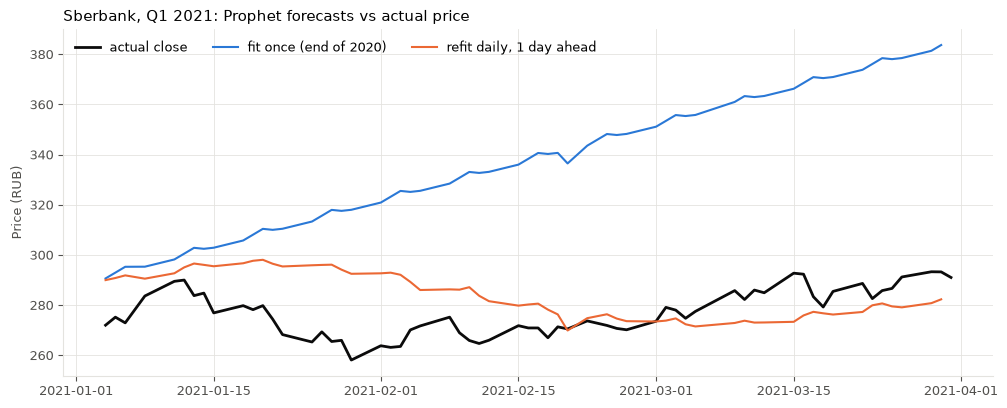

In [11]:
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3df"
SERIES = ["#2a78d6", "#eb6834"]

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED,
    "axes.titlesize": 11, "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 9,
    "legend.frameon": False, "lines.linewidth": 1.5,
})


def next_day_forecast(close, fc):
    """Each ``h1`` forecast, placed on the day it is a forecast for."""
    targets = close.index[close.index.get_indexer(fc.index) + 1]
    return pd.Series(fc["h1"].to_numpy(), index=targets)


close = prices["Russia"]
test = period(close, "test", EM_SPLITS)
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(test, color=INK, linewidth=2, label="actual close")
for (model, label), color in zip(
        [("prophet_once", "fit once (end of 2020)"),
         ("prophet_daily", "refit daily, 1 day ahead")], SERIES):
    path = next_day_forecast(close, forecasts["Russia", model])
    ax.plot(period(path, "test", EM_SPLITS), color=color, label=label)
ax.set_ylabel("Price (RUB)")
ax.set_title("Sberbank, Q1 2021: Prophet forecasts vs actual price")
ax.legend(loc="upper left", ncol=3)
plt.show()

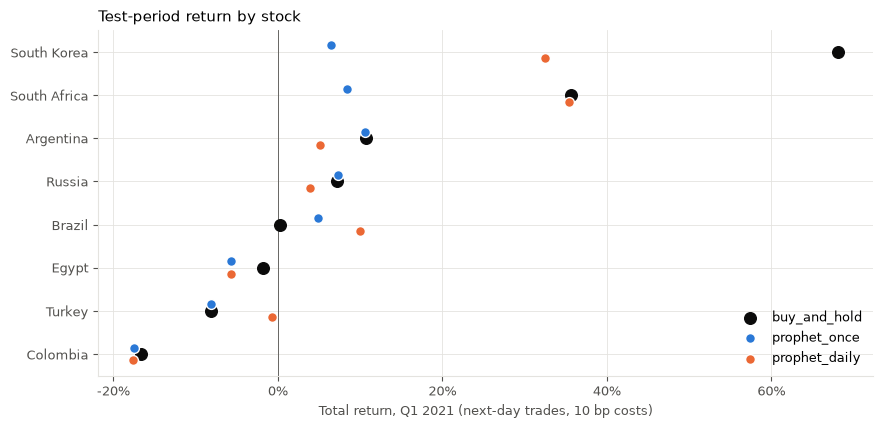

In [12]:
order = returns["buy_and_hold"].sort_values().index
fig, ax = plt.subplots(figsize=(10, 4.5))
y = range(len(order))
ax.scatter(returns.loc[order, "buy_and_hold"], y, s=70, color=INK,
           zorder=3, label="buy_and_hold")
# Small vertical offsets keep equal returns from hiding each other.
for model, color, dy in zip(["prophet_once", "prophet_daily"], SERIES,
                            [0.15, -0.15]):
    ax.scatter(returns.loc[order, model], [v + dy for v in y], s=50,
               color=color,
               edgecolor="white", linewidth=1, zorder=3, label=model)
ax.axvline(0, color=MUTED, linewidth=0.6)
ax.set_yticks(list(y), order)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlabel("Total return, Q1 2021 (next-day trades, 10 bp costs)")
ax.set_title("Test-period return by stock")
ax.legend(loc="lower right")
plt.show()

## What the results support

- **Prophet does not forecast tomorrow's price better than today's price
  does.** Refitting daily, its average one-day error is roughly two to
  six times the naive error, on every stock. Fitted once, it is far worse, because a
  forecast made in December drifts away from the price over the quarter.
- **Its up/down calls are no better than a coin flip.** The average hit
  rate is about 50%, close to what "always up" gets.
- **The trading rule earns less than buy-and-hold** on average for both
  versions, and beats it on only 2 of 8 stocks. It does reduce exposure
  (in the market about two-thirds of the time); the wins come from being
  out of the stock on some of the down days.
- **Sberbank shows how the earlier setup could mislead.** With same-day,
  cost-free trades, the fit-once model beats buy-and-hold on Sberbank
  (about 11% vs 7%). With next-day trades and costs, the edge is gone.

## Caveats

- The test period is about 60 trading days. Even a real edge would be
  hard to tell apart from luck over one quarter, so these results show
  the absence of evidence for an edge rather than proof there is none.
- Prices are in local currency and not adjusted for dividends.
- 10 bp is a low cost estimate for some of these markets, so real
  results for the active strategies would likely be worse.
- Prophet is designed for series with strong seasonal patterns (such as
  sales); daily stock prices have little of that, so poor forecasts are
  expected rather than a sign of a bug.